<a href="https://colab.research.google.com/github/jannatmoon1/Examining-the-Effectiveness-of-PCA-Based-Pooling-in-Convolutional-Neural-Networks/blob/main/PCApool_MNIST_Baseline_CNN%2C_Lenet%2C_Resnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install torchinfo scikit-learn pandas matplotlib tqdm

In [ ]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

from sklearn.metrics import f1_score

from torchinfo import summary

In [ ]:
class Config:

    # -------------------------
    # Dataset
    # -------------------------
    batch_size = 128
    num_workers = 2

    # -------------------------
    # Training
    # -------------------------
    lr = 1e-3
    weight_decay = 1e-4
    epochs = 15

    # -------------------------
    # Model
    # -------------------------
    num_classes = 10

    # -------------------------
    # Experiment
    # -------------------------
    seed = 42
    save_dir = "./mnist_pca_experiment"

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )


os.makedirs(Config.save_dir, exist_ok=True)

print("Device:", Config.device)

Device: cuda


In [ ]:
def set_seed(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(Config.seed)

In [ ]:
def get_mnist_loaders():

    transform_train = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    train_dataset = datasets.MNIST(
        root="./data",
        train=True,
        download=True,
        transform=transform_train
    )

    test_dataset = datasets.MNIST(
        root="./data",
        train=False,
        download=True,
        transform=transform_test
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=Config.batch_size,
        shuffle=True,
        num_workers=Config.num_workers,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=Config.batch_size,
        shuffle=False,
        num_workers=Config.num_workers,
        pin_memory=True
    )

    return train_loader, test_loader

In [ ]:
train_loader, test_loader = get_mnist_loaders()

print("Training samples:", len(train_loader.dataset))
print("Testing samples :", len(test_loader.dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 491kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.2MB/s]

Training samples: 60000
Testing samples : 10000


In [ ]:
class PCAPool2d(nn.Module):
    """
    PCA-Pooling layer following the paper:
    - Extract local windows
    - Form sample matrix A
    - PCA via SVD
    - Information-weighted pooling
    - Block rearrangement
    """

    def __init__(self, kernel_size=2, stride=2, out_dim=1, eps=1e-5):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = stride
        self.out_dim = out_dim
        self.eps = eps

    def forward(self, x):
        # x: [B, C, H, W]
        B, C, H, W = x.shape
        k = self.kernel_size

        # 1️⃣ Extract sliding windows
        patches = x.unfold(2, k, self.stride).unfold(3, k, self.stride)
        # [B, C, H', W', k, k]
        Hn, Wn = patches.size(2), patches.size(3)

        patches = patches.contiguous().view(B, C, Hn, Wn, -1)
        # [B, C, H', W', k*k]

        # 2️⃣ Build sample matrix A
        A = patches.view(-1, k * k)  # [B*C*H'*W', k*k]
        A_mean = A.mean(dim=0, keepdim=True)
        A_centered = A - A_mean

        # 3️⃣ PCA using SVD
        # A_centered = U S V^T
        U, S, Vh = torch.linalg.svd(A_centered, full_matrices=False)

        # Principal components
        Z = A_centered @ Vh.T  # [N, k*k]

        # 4️⃣ Information-weighted pooling
        # weights proportional to eigenvalues
        weights = S / (S.sum() + self.eps)
        Z_reduced = (Z[:, :self.out_dim] * weights[:self.out_dim])

        # 5️⃣ Block rearrangement
        out = Z_reduced.view(B, C, Hn, Wn, self.out_dim)
        out = out.mean(dim=-1)  # collapse PCA dimension

        return out

In [ ]:
def get_pool(pool_type):

    if pool_type == "max":
        return nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

    elif pool_type == "pca":
        return PCAPool2d(
            kernel_size=2,
            stride=2
        )

    else:
        raise ValueError(
            "pool_type must be 'max' or 'pca'"
        )

In [ ]:
class SimpleCNN(nn.Module):

    def __init__(
        self,
        num_classes=10,
        pool_type="max"
    ):

        super().__init__()

        self.pool_type = pool_type

        self.conv1 = nn.Conv2d(
            1, 32,
            kernel_size=3,
            padding=1
        )

        self.bn1 = nn.BatchNorm2d(32)

        self.pool1 = get_pool(pool_type)

        self.conv2 = nn.Conv2d(
            32, 64,
            kernel_size=3,
            padding=1
        )

        self.bn2 = nn.BatchNorm2d(64)

        self.pool2 = get_pool(pool_type)

        self.conv3 = nn.Conv2d(
            64, 128,
            kernel_size=3,
            padding=1
        )

        self.bn3 = nn.BatchNorm2d(128)

        self.global_pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Linear(
            128,
            num_classes
        )

    def forward(self, x):

        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)

        x = self.global_pool(x)

        x = torch.flatten(x, 1)

        return self.fc(x)

Resnet-18

In [ ]:
class BasicBlock(nn.Module):

    expansion = 1

    def __init__(
        self,
        in_channels,
        out_channels,
        stride=1
    ):

        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(
            out_channels
        )

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(
            out_channels
        )

        if (
            stride != 1
            or in_channels != out_channels
        ):

            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(
                    out_channels
                )
            )

        else:

            self.shortcut = nn.Identity()

    def forward(self, x):

        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity

        out = F.relu(out)

        return out

In [ ]:
class ResNet18(nn.Module):

    def __init__(
        self,
        num_classes=10,
        pool_type="max"
    ):

        super().__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(
            1,
            64,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(64)

        self.pool1 = get_pool(pool_type)
        self.pool2 = get_pool(pool_type)
        self.pool3 = get_pool(pool_type)

        self.layer1 = self._make_layer(
            64,
            2
        )

        self.layer2 = self._make_layer(
            128,
            2
        )

        self.layer3 = self._make_layer(
            256,
            2
        )

        self.layer4 = self._make_layer(
            512,
            2
        )

        self.avgpool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Linear(
            512,
            num_classes
        )

    def _make_layer(
        self,
        channels,
        blocks
    ):

        layers = []

        for _ in range(blocks):

            layers.append(
                BasicBlock(
                    self.in_channels,
                    channels
                )
            )

            self.in_channels = channels

        return nn.Sequential(*layers)

    def forward(self, x):

        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)

        # First downsampling
        x = self.pool1(x)

        x = self.layer1(x)

        # Second downsampling
        x = self.pool2(x)

        x = self.layer2(x)

        # Third downsampling
        x = self.pool3(x)

        x = self.layer3(x)

        x = self.layer4(x)

        x = self.avgpool(x)

        x = torch.flatten(x, 1)

        x = self.fc(x)

        return x

In [ ]:
class LeNet(nn.Module):

    def __init__(
        self,
        num_classes=10,
        pool_type="max"
    ):

        super().__init__()

        self.conv1 = nn.Conv2d(
            1, 6,
            kernel_size=5,
            padding=2
        )

        self.pool1 = get_pool(pool_type)

        self.conv2 = nn.Conv2d(
            6, 16,
            kernel_size=5
        )

        self.pool2 = get_pool(pool_type)

        self.conv3 = nn.Conv2d(
            16, 120,
            kernel_size=5
        )

        self.fc1 = nn.Linear(
            120,
            84
        )

        self.fc2 = nn.Linear(
            84,
            num_classes
        )

    def forward(self, x):

        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        x = F.relu(self.conv2(x))
        x = self.pool2(x)

        x = F.relu(self.conv3(x))

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))

        x = self.fc2(x)

        return x

Automatically creates any of the six models on our experiment

In [ ]:
def create_model(
    model_name,
    pool_type
):

    if model_name == "SimpleCNN":

        model = SimpleCNN(
            num_classes=Config.num_classes,
            pool_type=pool_type
        )

    elif model_name == "LeNet":

        model = LeNet(
            num_classes=Config.num_classes,
            pool_type=pool_type
        )

    elif model_name == "ResNet18":

        model = ResNet18(
            num_classes=Config.num_classes,
            pool_type=pool_type
        )

    else:

        raise ValueError(
            f"Unknown model: {model_name}"
        )

    return model.to(Config.device)

Function that calculates parameters

In [ ]:
def count_parameters(model):

    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

FLOPs

In [ ]:
!pip -q install thop

In [ ]:
from thop import profile

In [ ]:
def calculate_flops(model):

    model.eval()

    dummy = torch.randn(
        1, 1, 28, 28
    ).to(Config.device)

    try:

        flops, params = profile(
            model,
            inputs=(dummy,),
            verbose=False
        )

        return flops

    except Exception as e:

        print(
            "FLOPs calculation failed:",
            e
        )

        return np.nan

In [ ]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    start_time = time.perf_counter()

    for images, labels in loader:

        images = images.to(
            Config.device,
            non_blocking=True
        )

        labels = labels.to(
            Config.device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_time = (
        time.perf_counter()
        - start_time
    )

    loss = running_loss / total

    accuracy = 100.0 * correct / total

    return loss, accuracy, epoch_time

Evaluation function that calculates:
Loss
Accuracy
Macro F1

In [ ]:
@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion
):

    model.eval()

    running_loss = 0.0

    all_predictions = []
    all_labels = []

    total = 0
    correct = 0

    for images, labels in loader:

        images = images.to(
            Config.device,
            non_blocking=True
        )

        labels = labels.to(
            Config.device,
            non_blocking=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

    loss = running_loss / total

    accuracy = (
        100.0 * correct / total
    )

    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro"
    )

    return loss, accuracy, macro_f1

Inference time

In [ ]:
@torch.no_grad()
def measure_inference_time(
    model,
    loader,
    warmup_batches=10
):

    model.eval()

    # Warm-up
    for i, (images, _) in enumerate(loader):

        images = images.to(
            Config.device,
            non_blocking=True
        )

        _ = model(images)

        if i + 1 >= warmup_batches:
            break

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start = time.perf_counter()

    total_images = 0

    for images, _ in loader:

        images = images.to(
            Config.device,
            non_blocking=True
        )

        _ = model(images)

        total_images += images.size(0)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - start

    ms_per_image = (
        elapsed / total_images
    ) * 1000

    return elapsed, ms_per_image

Peak GPU memory

In [ ]:
def measure_peak_memory():

    if torch.cuda.is_available():

        return (
            torch.cuda.max_memory_allocated()
            / (1024 ** 2)
        )

    return np.nan

In [ ]:
def run_experiment(
    model_name,
    pool_type,
    train_loader,
    test_loader
):

    print("\n" + "=" * 70)

    print(
        f"MODEL: {model_name} | "
        f"POOL: {pool_type.upper()}"
    )

    print("=" * 70)

    set_seed(Config.seed)

    model = create_model(
        model_name,
        pool_type
    )

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=Config.lr,
        weight_decay=Config.weight_decay
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=Config.epochs
    )

    # -------------------------
    # Parameters
    # -------------------------

    parameters = count_parameters(model)

    # -------------------------
    # FLOPs
    # -------------------------

    flops = calculate_flops(model)

    # -------------------------
    # GPU memory reset
    # -------------------------

    if torch.cuda.is_available():

        torch.cuda.empty_cache()

        torch.cuda.reset_peak_memory_stats()

    # -------------------------
    # History
    # -------------------------

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": [],
        "test_f1": [],
        "epoch_time": []
    }

    best_accuracy = 0.0
    convergence_epoch = Config.epochs

    total_training_start = time.perf_counter()

    # -------------------------
    # Training
    # -------------------------

    for epoch in range(1, Config.epochs + 1):

        train_loss, train_acc, epoch_time = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        test_loss, test_acc, test_f1 = evaluate(
            model,
            test_loader,
            criterion
        )

        scheduler.step()

        # Save history

        history["train_loss"].append(
            train_loss
        )

        history["train_accuracy"].append(
            train_acc
        )

        history["test_loss"].append(
            test_loss
        )

        history["test_accuracy"].append(
            test_acc
        )

        history["test_f1"].append(
            test_f1
        )

        history["epoch_time"].append(
            epoch_time
        )

        # Best accuracy

        if test_acc > best_accuracy:

            best_accuracy = test_acc
            convergence_epoch = epoch

        # Print per epoch

        print(
            f"Epoch [{epoch:02d}/{Config.epochs}] "
            f"| Train Loss: {train_loss:.4f} "
            f"| Train Acc: {train_acc:.2f}% "
            f"| Test Loss: {test_loss:.4f} "
            f"| Test Acc: {test_acc:.2f}% "
            f"| Macro F1: {test_f1:.4f} "
            f"| Time: {epoch_time:.2f}s"
        )

    total_training_time = (
        time.perf_counter()
        - total_training_start
    )

    # -------------------------
    # Final evaluation
    # -------------------------

    final_loss, final_accuracy, final_f1 = evaluate(
        model,
        test_loader,
        criterion
    )

    # -------------------------
    # Inference
    # -------------------------

    inference_time, ms_per_image = measure_inference_time(
        model,
        test_loader
    )

    # -------------------------
    # Peak memory
    # -------------------------

    peak_memory = measure_peak_memory()

    # -------------------------
    # Result
    # -------------------------

    result = {

        "Model": model_name,

        "Pooling": pool_type,

        "Top-1 Accuracy (%)":
            final_accuracy,

        "Macro F1":
            final_f1,

        "Parameters":
            parameters,

        "Parameters (M)":
            parameters / 1e6,

        "FLOPs":
            flops,

        "FLOPs (M)":
            flops / 1e6
            if not np.isnan(flops)
            else np.nan,

        "Training Time (s)":
            total_training_time,

        "Inference Time (s)":
            inference_time,

        "Inference (ms/image)":
            ms_per_image,

        "Peak GPU Memory (MB)":
            peak_memory,

        "Convergence Epoch":
            convergence_epoch
    }

    return model, history, result

In [ ]:
models = [
    "SimpleCNN",
    "LeNet",
    "ResNet18"
]

pooling_methods = [
    "max",
    "pca"
]

In [ ]:
all_results = {}
results_table = []

for model_name in models:

    for pool_type in pooling_methods:

        model, history, result = run_experiment(
            model_name,
            pool_type,
            train_loader,
            test_loader
        )

        key = f"{model_name}_{pool_type}"

        all_results[key] = {
            "model": model,
            "history": history,
            "result": result
        }

        results_table.append(result)


MODEL: SimpleCNN | POOL: MAX
Epoch [01/15] | Train Loss: 0.4107 | Train Acc: 91.78% | Test Loss: 0.1458 | Test Acc: 96.22% | Macro F1: 0.9621 | Time: 13.02s
Epoch [02/15] | Train Loss: 0.0894 | Train Acc: 97.72% | Test Loss: 0.1292 | Test Acc: 96.51% | Macro F1: 0.9648 | Time: 14.63s
Epoch [03/15] | Train Loss: 0.0592 | Train Acc: 98.38% | Test Loss: 0.1748 | Test Acc: 94.71% | Macro F1: 0.9469 | Time: 13.18s
Epoch [04/15] | Train Loss: 0.0453 | Train Acc: 98.79% | Test Loss: 0.0735 | Test Acc: 97.81% | Macro F1: 0.9780 | Time: 13.10s
Epoch [05/15] | Train Loss: 0.0361 | Train Acc: 99.03% | Test Loss: 0.0771 | Test Acc: 97.59% | Macro F1: 0.9759 | Time: 12.67s
Epoch [06/15] | Train Loss: 0.0300 | Train Acc: 99.18% | Test Loss: 0.0675 | Test Acc: 97.86% | Macro F1: 0.9784 | Time: 13.10s
Epoch [07/15] | Train Loss: 0.0243 | Train Acc: 99.36% | Test Loss: 0.0485 | Test Acc: 98.60% | Macro F1: 0.9860 | Time: 13.74s
Epoch [08/15] | Train Loss: 0.0189 | Train Acc: 99.50% | Test Loss: 0.0845

In [ ]:
results_df = pd.DataFrame(
    results_table
)

results_df = results_df.round(4)

results_df

,Model,Pooling,Top-1 Accuracy (%),Macro F1,Parameters,Parameters (M),FLOPs,FLOPs (M),Training Time (s),Inference Time (s),Inference (ms/image),Peak GPU Memory (MB),Convergence Epoch
0,SimpleCNN,max,98.93,0.9892,94410,0.0944,7634432.0,7.6344,230.1906,1.8579,0.1858,90.6987,15
1,SimpleCNN,pca,99.27,0.9926,94410,0.0944,7634432.0,7.6344,270.7067,2.1276,0.2128,890.2051,14
2,LeNet,max,99.15,0.9914,61706,0.0617,416520.0,0.4165,222.5970,2.6489,0.2649,38.8711,15
3,LeNet,pca,98.84,0.9884,61706,0.0617,416520.0,0.4165,255.1543,2.0549,0.2055,183.4775,9
4,ResNet18,max,99.52,0.9951,11172810,11.1728,150090240.0,150.0902,343.6004,2.6867,0.2687,411.4692,12
5,ResNet18,pca,99.59,0.9959,11172810,11.1728,150090240.0,150.0902,533.7128,2.7791,0.2779,1995.5215,14


In [ ]:
def plot_accuracy_comparison(results_df):

    models = [
        "SimpleCNN",
        "LeNet",
        "ResNet18"
    ]

    max_acc = []
    pca_acc = []

    for model in models:

        max_value = results_df[
            (results_df["Model"] == model) &
            (results_df["Pooling"] == "max")
        ]["Top-1 Accuracy (%)"].values[0]

        pca_value = results_df[
            (results_df["Model"] == model) &
            (results_df["Pooling"] == "pca")
        ]["Top-1 Accuracy (%)"].values[0]

        max_acc.append(max_value)
        pca_acc.append(pca_value)

    x = np.arange(len(models))

    width = 0.35

    plt.figure(figsize=(9, 5))

    plt.bar(
        x - width/2,
        max_acc,
        width,
        label="MaxPool"
    )

    plt.bar(
        x + width/2,
        pca_acc,
        width,
        label="PCAPool"
    )

    plt.xticks(
        x,
        models
    )

    plt.ylabel("Top-1 Accuracy (%)")

    plt.xlabel("CNN Architecture")

    plt.title(
        "MNIST Accuracy: MaxPool vs PCAPool"
    )

    plt.legend()

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

In [ ]:
def plot_training_history(
    all_results,
    model_name
):

    max_key = f"{model_name}_max"
    pca_key = f"{model_name}_pca"

    max_history = all_results[
        max_key
    ]["history"]

    pca_history = all_results[
        pca_key
    ]["history"]

    epochs = range(
        1,
        Config.epochs + 1
    )

    # -------------------------
    # Loss
    # -------------------------

    plt.figure(figsize=(9, 5))

    plt.plot(
        epochs,
        max_history["train_loss"],
        label="MaxPool Train"
    )

    plt.plot(
        epochs,
        max_history["test_loss"],
        linestyle="--",
        label="MaxPool Test"
    )

    plt.plot(
        epochs,
        pca_history["train_loss"],
        label="PCAPool Train"
    )

    plt.plot(
        epochs,
        pca_history["test_loss"],
        linestyle="--",
        label="PCAPool Test"
    )

    plt.xlabel("Epoch")

    plt.ylabel("Loss")

    plt.title(
        f"{model_name}: Training and Test Loss"
    )

    plt.legend()

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()

    # -------------------------
    # Accuracy
    # -------------------------

    plt.figure(figsize=(9, 5))

    plt.plot(
        epochs,
        max_history["train_accuracy"],
        label="MaxPool Train"
    )

    plt.plot(
        epochs,
        max_history["test_accuracy"],
        linestyle="--",
        label="MaxPool Test"
    )

    plt.plot(
        epochs,
        pca_history["train_accuracy"],
        label="PCAPool Train"
    )

    plt.plot(
        epochs,
        pca_history["test_accuracy"],
        linestyle="--",
        label="PCAPool Test"
    )

    plt.xlabel("Epoch")

    plt.ylabel("Accuracy (%)")

    plt.title(
        f"{model_name}: Training and Test Accuracy"
    )

    plt.legend()

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()

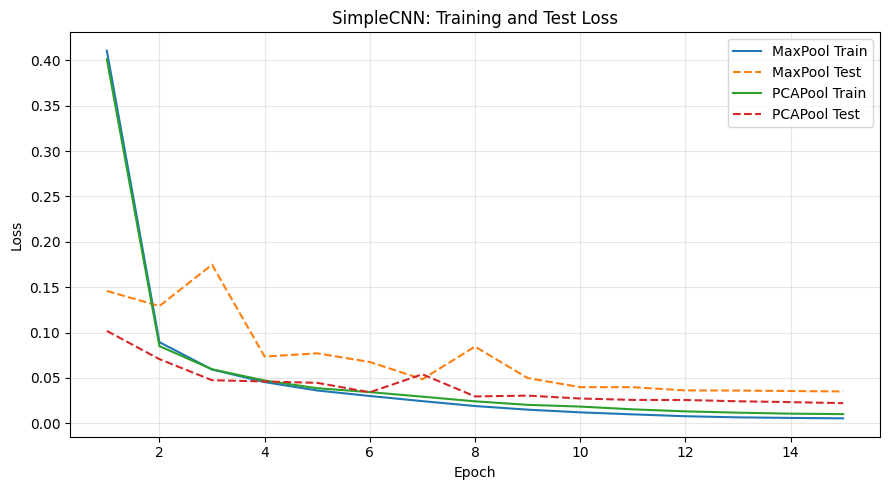

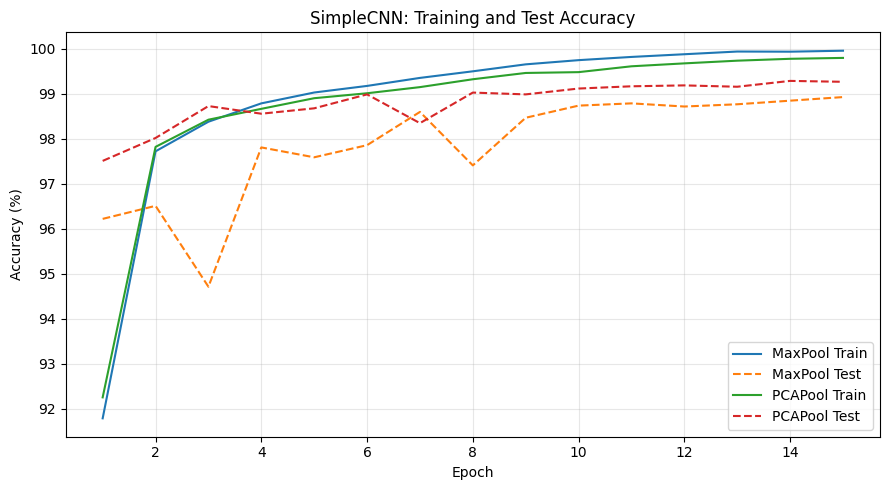

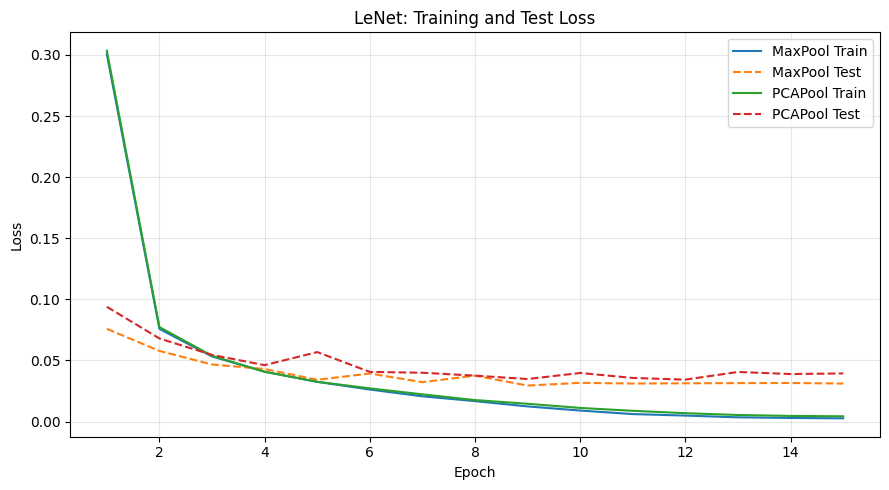

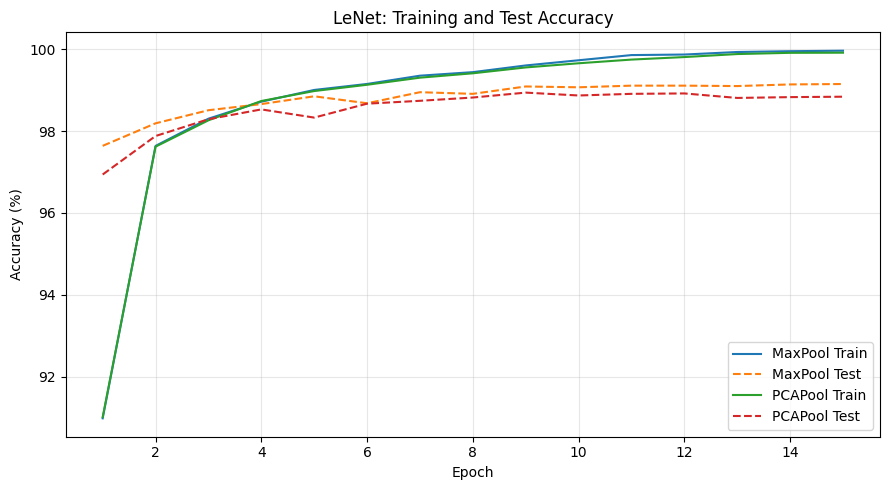

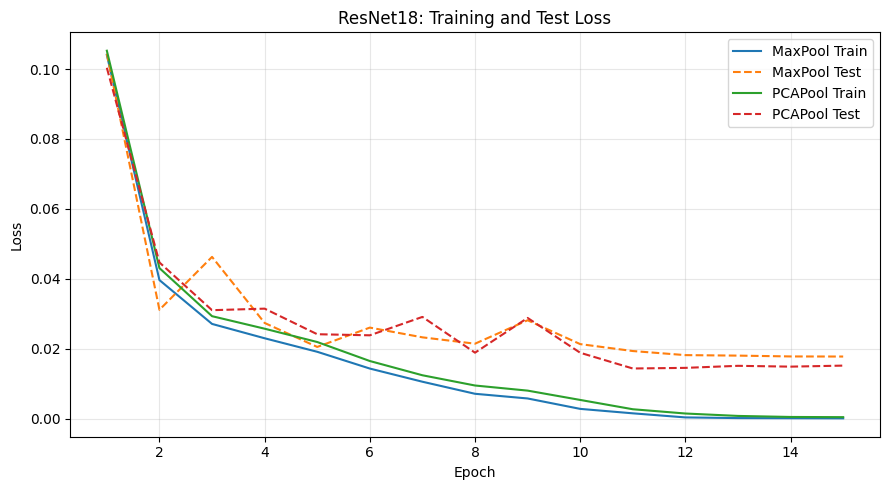

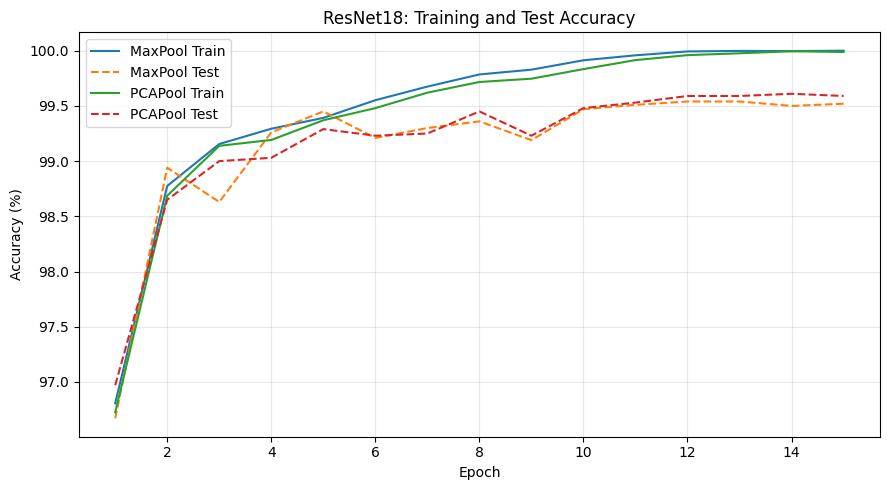

In [ ]:
for model_name in models:

    plot_training_history(
        all_results,
        model_name
    )

In [ ]:
results_path = os.path.join(
    Config.save_dir,
    "mnist_results.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

print(
    "Saved:",
    results_path
)

Saved: ./mnist_pca_experiment/mnist_results.csv


In [ ]:
for key, value in all_results.items():

    model_path = os.path.join(
        Config.save_dir,
        f"{key}.pth"
    )

    torch.save(
        value["model"].state_dict(),
        model_path
    )

    print(
        "Saved:",
        model_path
    )

Saved: ./mnist_pca_experiment/SimpleCNN_max.pth
Saved: ./mnist_pca_experiment/SimpleCNN_pca.pth
Saved: ./mnist_pca_experiment/LeNet_max.pth
Saved: ./mnist_pca_experiment/LeNet_pca.pth
Saved: ./mnist_pca_experiment/ResNet18_max.pth
Saved: ./mnist_pca_experiment/ResNet18_pca.pth
